
# 🧠 Week 1 — Introduction to AI Engineering
### How Do Language Models Actually Work?

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/lectures/intro_lecture_student.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

---

### 🎯 Learning Objectives
By the end of this week, you should be able to:
- Explain what a Large Language Model (LLM) is — and what it is *not*.
- Describe how an LLM is trained to predict the next token.
- Relate that training process to regression and error minimization.
- Understand how additional learning makes models follow instructions.
- Identify where trust and failure may arise in a simple *User → Prompt → Model → Output* system.



## 🧩 What LLMs Are (and Aren’t)
**Where would you trust or not trust AI?**

Let's explore how AI can sound fluent but still make mistakes.

**Why can AI write poetry but invent fake citations?**


In [ ]:
haiku = 'Tulips in the sun\nWhisper quiet algorithms\nLearning to blossom'
citation = 'Smith, J. (2024). Quantum Tulips and AI Poetry. *Nature*, 12(3), 45-47.'
print('Haiku Example:\n', haiku)
print('\nCitation Example:\n', citation)

Haiku Example:
 Tulips in the sun
Whisper quiet algorithms
Learning to blossom

Citation Example:
 Smith, J. (2024). Quantum Tulips and AI Poetry. *Nature*, 12(3), 45-47.


💬 *Reflection:* Why does the first feel “right,” even though it’s nonsense, while the second fails despite sounding formal?


## 🔢 How does a language model decide what word comes next?

An LLM predicts the next token based on all the previous ones.

$$P(w_t \mid w_1, \dots, w_{t-1}) = \frac{e^{s(w_t)}}{\sum_j e^{s(w_j)}}$$


In [ ]:
import numpy as np
from scipy.special import softmax

tokens = ['cat', 'dog', 'banana', 'quantum']
scores = np.array([2.0, 1.0, 0.5, -1.0])
probs = softmax(scores)

for t, p in zip(tokens, probs):
    print(f'{t:>8s}: {p:.3f}')

     cat: 0.609
     dog: 0.224
  banana: 0.136
 quantum: 0.030


Let's visualize this distribution to make it clearer.

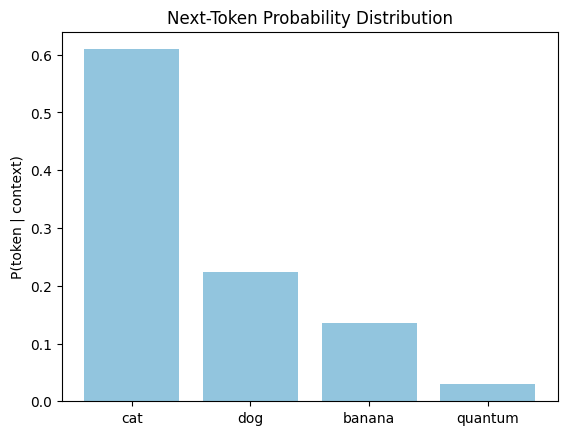

In [ ]:
import matplotlib.pyplot as plt

plt.bar(tokens, probs, color='#92c5de')
plt.title('Next-Token Probability Distribution')
plt.ylabel('P(token | context)')
plt.show()


## 🧠 How Do LLMs Learn?

**If language models learn to predict the next word, how do they get good at answering questions or following instructions?**



### Step 1 — Learning to Predict

At first, a model is trained on massive amounts of text to predict the next word.  
This is like regression: it adjusts internal weights to reduce error between predicted and true words.

$$\text{Loss} = -\sum P_{\text{true}}(w)\,\log P_{\text{model}}(w)$$

It keeps tuning these parameters until it gets better and better at guessing what word should come next.


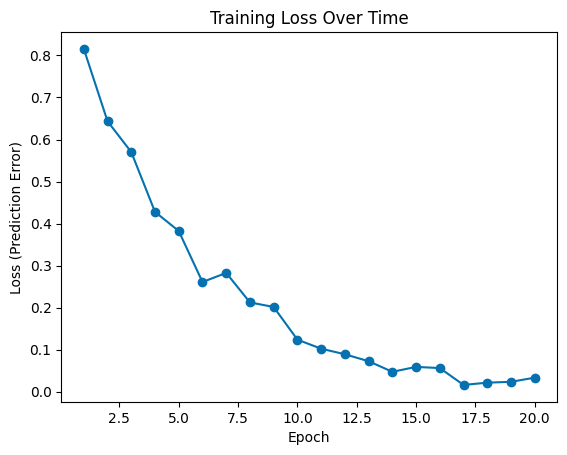

In [ ]:
import numpy as np, matplotlib.pyplot as plt
epochs = np.arange(1, 21)
loss = np.exp(-epochs/5) + np.random.normal(0, 0.02, len(epochs))
plt.plot(epochs, loss, marker='o', color='#0571b0')
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss (Prediction Error)')
plt.show()

💡 *Just like regression minimizes the distance between predicted and actual values, the model minimizes loss for next-word predictions.*


### Step 2 — Scaling Up

So how much text does a model need to read to get good at this? Let's look at scale.


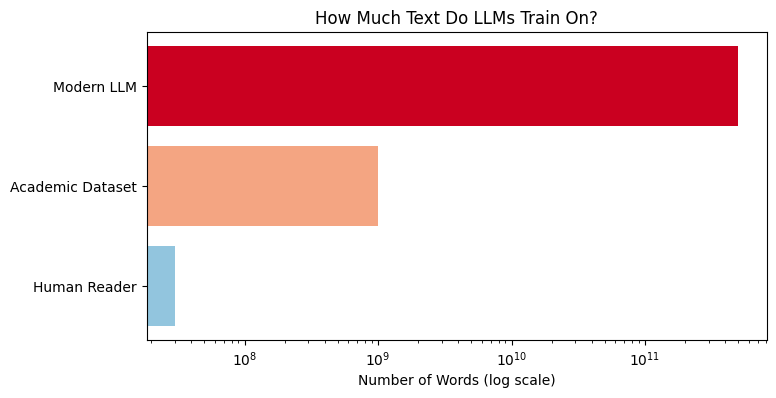

In [ ]:
labels = ['Human Reader', 'Academic Dataset', 'Modern LLM']
words = [3e7, 1e9, 5e11]
plt.figure(figsize=(8, 4))
plt.barh(labels, words, color=['#92c5de', '#f4a582', '#ca0020'])
plt.xscale('log')
plt.xlabel('Number of Words (log scale)')
plt.title('How Much Text Do LLMs Train On?')
plt.show()

A modern LLM reads more text than any human could in hundreds of lifetimes.


### Step 3 — Learning to Follow Instructions

Once trained on text, the model can generate fluent language — but not necessarily *helpful* answers.  
To bridge this gap, developers show it examples of how people ask and answer questions, and collect human feedback on what “good” responses look like.

Gradually, the model learns to follow instructions, stay on topic, and respond more like a conversational partner.

*(We’ll explore how this feedback process works in more detail in Week 7 when we talk about safety and reliability.)*



💬 *Reflection:* If a model reads so much text, why does human feedback still matter?  
What kinds of behavior might we need to **teach** it after pre-training?



## 🔄 What’s the simplest way to think about an AI system?


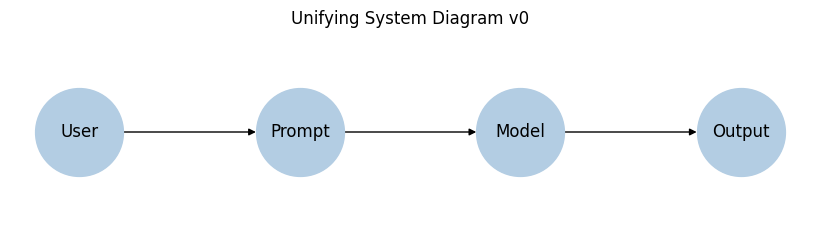

In [ ]:
import networkx as nx
G = nx.DiGraph()
G.add_edges_from([('User', 'Prompt'), ('Prompt', 'Model'), ('Model', 'Output')])
pos = {'User': (0, 0), 'Prompt': (1, 0), 'Model': (2, 0), 'Output': (3, 0)}
plt.figure(figsize=(8, 2))
nx.draw(G, pos, with_labels=True, node_size=4000, node_color='#b3cde3', font_size=12, arrows=True)
plt.title('Unifying System Diagram v0')
plt.show()

💬 *Think about it:* Where could things go wrong in this flow? How might we measure or log each stage?


## ⚙️ What is Google Colab, and why are we using it?
Colab lets us run Python notebooks in the cloud — no installation, just your browser.

Try running this cell below.


In [ ]:
print('Hello, AI Engineering world!')

Hello, AI Engineering world!



## 🌐 What happens when we send a request to an API model?


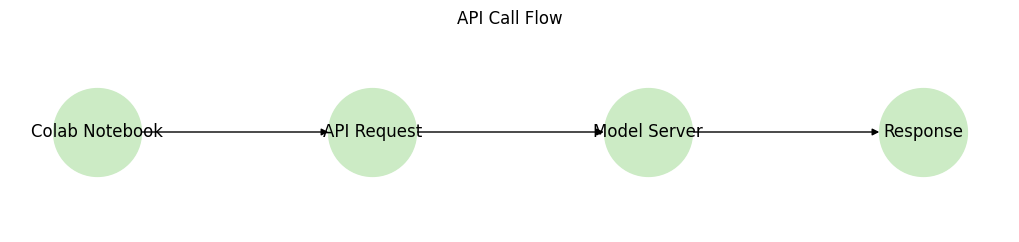

In [ ]:
G = nx.DiGraph()
edges = [('Colab Notebook', 'API Request'), ('API Request', 'Model Server'), ('Model Server', 'Response')]
G.add_edges_from(edges)
pos = {'Colab Notebook': (0, 0), 'API Request': (1, 0), 'Model Server': (2, 0), 'Response': (3, 0)}
plt.figure(figsize=(10, 2))
nx.draw(G, pos, with_labels=True, node_size=4000, node_color='#ccebc5', font_size=12, arrows=True)
plt.title('API Call Flow')
plt.show()

In [ ]:
import time, random

def simulate_api_call():
    latency = random.uniform(0.2, 1.2)
    print(f'Sending request... (latency ≈ {latency:.2f}s)')
    time.sleep(latency)
    print('Response received!')

simulate_api_call()

Sending request... (latency ≈ 0.39s)
Response received!



## 💸 How much does a single model call cost?
Model APIs charge by *tokens* (roughly words).

$$\text{Cost} = \frac{N_{tokens}}{1000} \times r_{\text{per 1K}}$$


In [ ]:
def estimate_cost(num_calls=10, avg_tokens=300, rate_per_1k=0.002):
    total_tokens = num_calls * avg_tokens
    cost = total_tokens / 1000 * rate_per_1k
    print(f'Estimated total cost: ${cost:.4f} for {num_calls} calls')
    return cost

estimate_cost()

Estimated total cost: $0.0060 for 10 calls


0.006

💬 *Discussion:* Why does cost matter when designing an AI system? How might engineers reduce it?


## 💬 Reflection
> In your own words, describe the “LLM system.”  
> What part feels most interesting or confusing to you right now?



## 🗂️ Instructor Notes

<details>
<summary>Show Instructor Notes</summary>

**Suggested Flow**  
- Haiku vs Citation motivation  
- Probability model + softmax example  
- New: *How LLMs Learn* (regression analogy, loss figure, data scale visual)  
- System Diagram v0 discussion  
- Colab demo  
- API flow + latency simulation  
- Cost estimation and reflection  

**Slide Cues**  
1. Haiku/Citation examples  
2. Probability equation and bar chart  
3. Training loss + data scale visual  
4. System Diagram v0  
5. API Call Flow  
6. Summary + Transition to Lab 01  

**Transitions**  
- End of Day 1 → “Next week, we’ll add randomness and diversity.”  
- End of Day 2 → “Now open `intro_lab.ipynb` to make your first real API call.”

</details>
